In [1]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

In [2]:
current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    if (parent / "src").exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
else:
    raise FileNotFoundError("Could not find project root.")

from src.config import (
    TRAIN_DATA, TEST_DATA, MODEL_DIR, 
    T_MODEL_PATH, C_MODEL_PATH, 
    FEATURES, TARGET, TREATMENT
)

In [4]:
print("Loading Test Data")
test_df = pd.read_parquet(TEST_DATA)
X_test = test_df[FEATURES]

print("Loading T-Learner")
t_model_t = joblib.load(T_MODEL_PATH)
t_model_c = joblib.load(C_MODEL_PATH)

print("Loading X-Learner")
try:
    x_artifacts = joblib.load(MODEL_DIR / "x_learner_artifacts.joblib")
    tau_1 = x_artifacts['tau_1']   
    tau_0 = x_artifacts['tau_0']   
    g_model = x_artifacts['g_model']
    print("X-Learner loaded successfully.")
except FileNotFoundError:
    print("X-Learner artifacts not found!")

Loading Test Data
Loading T-Learner
Loading X-Learner
X-Learner loaded successfully.


In [5]:
print("Calculating T-Learner Uplift")
# T-Learner: Simple difference of means
p_t = t_model_t.predict_proba(X_test)[:, 1]
p_c = t_model_c.predict_proba(X_test)[:, 1]
test_df['uplift_t'] = p_t - p_c

print("Calculating X-Learner Uplift.")
# X-Learner: Weighted average of two effect estimators
# Uplift = g(x)*tau_0(x) + (1-g(x))*tau_1(x)
propensity = g_model.predict_proba(X_test)[:, 1]
effect_0 = tau_0.predict(X_test) 
effect_1 = tau_1.predict(X_test) 

test_df['uplift_x'] = (propensity * effect_0) + ((1 - propensity) * effect_1)

print("Predictions complete.")
print(test_df[['uplift_t', 'uplift_x']].describe())

Calculating T-Learner Uplift
Calculating X-Learner Uplift.
Predictions complete.
           uplift_t      uplift_x
count  2.797317e+06  2.797317e+06
mean   1.140507e-03  9.325360e-04
std    1.235107e-02  1.222322e-02
min   -7.774870e-01 -8.879260e-01
25%    9.747963e-05  2.895354e-05
50%    2.463491e-04  4.486568e-05
75%    2.907969e-04  1.751124e-04
max    5.191985e-01  1.437583e+00


In [6]:
def get_qini_data(df, score_col, target_col, treat_col):
    # Sort by Uplift Score descending
    df_sorted = df.sort_values(by=score_col, ascending=False).copy()
    
    # Cumulative stats
    df_sorted['n_treatment'] = (df_sorted[treat_col] == 1).cumsum()
    df_sorted['n_control'] = (df_sorted[treat_col] == 0).cumsum()
    df_sorted['n_y_treatment'] = ((df_sorted[treat_col] == 1) & (df_sorted[target_col] == 1)).cumsum()
    df_sorted['n_y_control'] = ((df_sorted[treat_col] == 0) & (df_sorted[target_col] == 1)).cumsum()
    
    # Normalizing factor
    N_t = df_sorted[treat_col].sum()
    N_c = (1 - df_sorted[treat_col]).sum()
    
    # Qini Gain = Y_t - (Y_c * N_t / N_c)
    df_sorted['qini_gain'] = df_sorted['n_y_treatment'] - (df_sorted['n_y_control'] * N_t / N_c)
    
    # Random Curve (Straight line)
    total_gain = df_sorted['qini_gain'].iloc[-1]
    df_sorted['random_gain'] = np.linspace(0, total_gain, len(df_sorted))
    
    # Population %
    df_sorted['pop_percent'] = np.linspace(0, 1, len(df_sorted))
    
    return df_sorted[['pop_percent', 'qini_gain', 'random_gain']]

/accounts/masters/quannm/uplift_project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


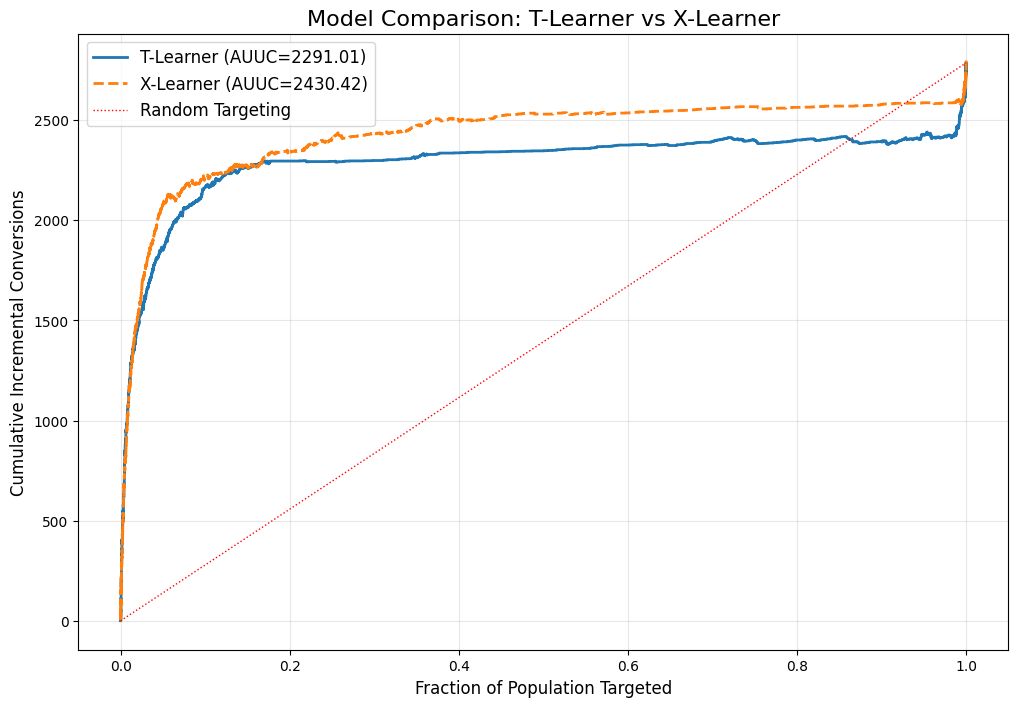

In [7]:
qini_t = get_qini_data(test_df, 'uplift_t', TARGET, TREATMENT)
qini_x = get_qini_data(test_df, 'uplift_x', TARGET, TREATMENT)

auuc_t = auc(qini_t['pop_percent'], qini_t['qini_gain'])
auuc_x = auc(qini_x['pop_percent'], qini_x['qini_gain'])

plt.figure(figsize=(12, 8))

# Plot T-Learner
plt.plot(qini_t['pop_percent'], qini_t['qini_gain'], 
         label=f'T-Learner (AUUC={auuc_t:.2f})', linewidth=2)

# Plot X-Learner
plt.plot(qini_x['pop_percent'], qini_x['qini_gain'], 
         label=f'X-Learner (AUUC={auuc_x:.2f})', linewidth=2, linestyle='--')

# Plot Random
plt.plot(qini_t['pop_percent'], qini_t['random_gain'], 
         'r:', label='Random Targeting', linewidth=1)

plt.title('Model Comparison: T-Learner vs X-Learner', fontsize=16)
plt.xlabel('Fraction of Population Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Conversions', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

The X-Learner (Orange) achieves an AUUC of 2430, beating the T-Learner (Blue, 2291) by ~6.1%. This validates the decision to implement the more advanced meta-learner.

The X-Learner curve (orange dashed line) stays above the T-Learner curve for almost the entire population range. This visually proves that the X-Learner is effectively better at ranking users from best to worst across the board.

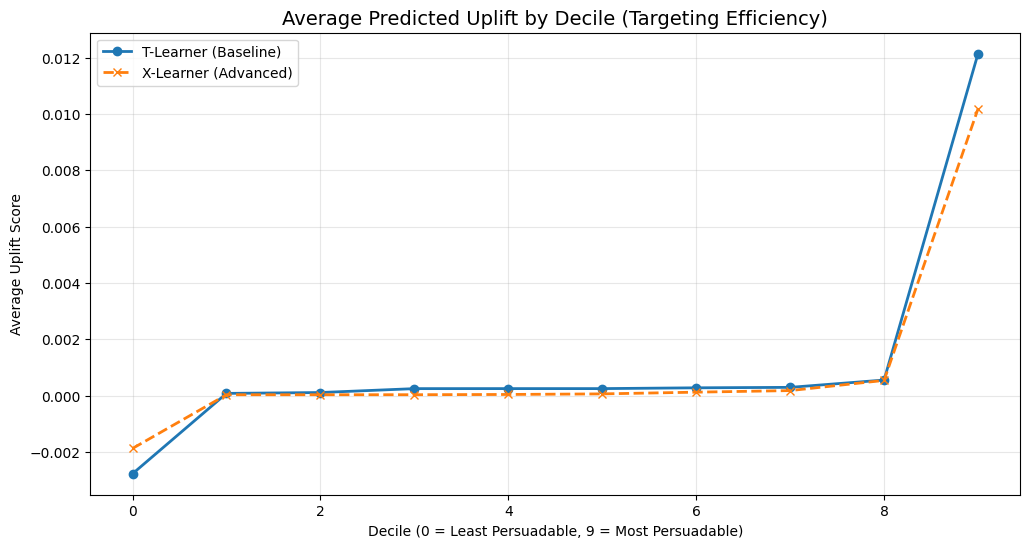

In [9]:
test_df['decile_t'] = pd.qcut(test_df['uplift_t'].rank(method='first'), 10, labels=False)
test_df['decile_x'] = pd.qcut(test_df['uplift_x'].rank(method='first'), 10, labels=False)

# Calculate average uplift per decile
lift_t = test_df.groupby('decile_t')['uplift_t'].mean()
lift_x = test_df.groupby('decile_x')['uplift_x'].mean()

plt.figure(figsize=(12, 6))
plt.plot(lift_t.index, lift_t.values, marker='o', label='T-Learner (Baseline)', linewidth=2)
plt.plot(lift_x.index, lift_x.values, marker='x', label='X-Learner (Advanced)', linewidth=2, linestyle='--')

plt.title('Average Predicted Uplift by Decile (Targeting Efficiency)', fontsize=14)
plt.xlabel('Decile (0 = Least Persuadable, 9 = Most Persuadable)')
plt.ylabel('Average Uplift Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Concentrated Value: The sharp spike in Decile 9 confirms that the "Persuadable" population is highly concentrated. Targeting just this top 10% yields massive incremental returns compared to the flat response of the middle 80%.

"Sleeping Dog" Detection: Both models successfully identify users in Decile 0 with negative uplift (values below 0). This proves the agent can detect users who are repelled by advertising, allowing you to suppress bids and save budget.